In [1]:
#| default_exp _trainer

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#| export
import torch
import matplotlib.pyplot as plt
from dreamer4._core import build_tiny_pinpad_dataset, make_tiny_dataloader, build_pinpad_datasets_for_trainers
from dreamer4.dreamer4 import VideoTokenizer, DynamicsWorldModel
from dreamer4.trainers import VideoTokenizerTrainer, SimTrainer, cycle, BehaviorCloneTrainer

/home/j/workspace/dreamer4/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
CPU = False
neps = 1
device = 'cuda' if not CPU else 'cpu'
dataset, env = build_tiny_pinpad_dataset(device=device, episode_length=100, n=neps)

pads {'3', '2', '1'} target ('1', '2', '3')

Built tiny PinPad dataset with 1 videos of shape torch.Size([3, 100, 64, 64]) - (c, t, h, w). Success rate 100.0%


In [5]:
# 1) Build datasets
tok_ds, bc_ds, env = build_pinpad_datasets_for_trainers(
    n_episodes=200,
    episode_length=100,
    tok_window=16,
    device='cpu',
    use_motion_planner=True
)


pads {'3', '2', '1'} target ('1', '2', '3')

pads {'3', '2', '1'} target ('1', '2', '3')



In [6]:
import torch
import matplotlib.pyplot as plt

def get_video_from_sample(sample):
    """Return a (C,T,H,W) or (T,C,H,W) tensor from dict/tuple/tensor samples."""
    if isinstance(sample, dict):
        v = sample.get("video", next((x for x in sample.values() if torch.is_tensor(x)), None))
    elif isinstance(sample, (list, tuple)):
        # common case: TensorDataset(videos) -> (video,)
        v = sample[0]
    else:
        v = sample
    if not torch.is_tensor(v):
        raise TypeError(f"Couldn't find a tensor video in sample of type {type(sample)}")
    return v

def canonicalize_cthw(v):
    """Ensure (C,T,H,W); convert dtype/range for visibility."""
    if v.ndim != 4:
        raise ValueError(f"Expected 4D video, got shape {tuple(v.shape)}")
    # If first dim isn't channels, assume (T,C,H,W) and permute
    if v.shape[0] not in (1,3):
        v = v.permute(1,0,2,3).contiguous()  # (T,C,H,W) -> (C,T,H,W)
    # Make float in [0,1] for viewing
    if v.dtype.is_floating_point:
        # if it looks zero-centered, de-normalize (heuristic)
        if v.min() < 0:
            v = (v * 0.5) + 0.5
        v = v.clamp(0,1)
    else:
        v = v.float() / 255.0
    return v

def peek_video(sample, title="sample", t=0):
    v = get_video_from_sample(sample)
    print(f"{title} raw:", v.shape, v.dtype, "min/max:", float(v.min()), float(v.max()))
    v = canonicalize_cthw(v)
    C,T,H,W = v.shape
    img = v[:, min(t,T-1)].permute(1,2,0).cpu().numpy()
    print(f"{title} canonical:", v.shape, v.dtype, "min/max:", float(v.min()), float(v.max()))
    plt.figure(figsize=(3,3)); plt.imshow(img); plt.title(f"{title} t={min(t,T-1)}"); plt.axis("off"); plt.show()
    return v


tok_ds[0] raw: torch.Size([3, 16, 64, 64]) torch.float32 min/max: -1.0 1.0
tok_ds[0] canonical: torch.Size([3, 16, 64, 64]) torch.float32 min/max: 0.0 1.0


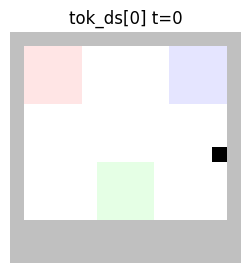

bc_ds[0] raw: torch.Size([3, 16, 64, 64]) torch.float32 min/max: -1.0 1.0
bc_ds[0] canonical: torch.Size([3, 16, 64, 64]) torch.float32 min/max: 0.0 1.0


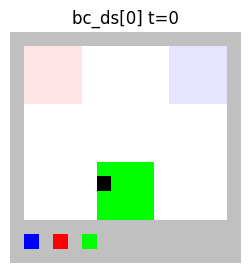

In [7]:

# Use on both datasets:
v_tok = peek_video(tok_ds[0], title="tok_ds[0]")
v_bc  = peek_video(bc_ds[0],  title="bc_ds[0]")


In [8]:
## DEBUG MEMORY ##

import torch
import gc
import psutil

def format_bytes(size):
    power = 2**10
    n = 0
    power_labels = {0 : '', 1: 'K', 2: 'M', 3: 'G', 4: 'T'}
    while size > power:
        size /= power
        n += 1
    return f"{size:.2f} {power_labels[n]}B"

def audit_gpu_memory():
    """
    Prints a breakdown of what is currently on the GPU.
    Safely handles torch.compile Symbolic/FakeTensors.
    """
    if not torch.cuda.is_available():
        print("CUDA is not available.")
        return

    print("\n--- GPU MEMORY AUDIT ---")
    
    # 1. Global Stats
    try:
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        print(f"Total Allocated (Tensors): {format_bytes(allocated)}")
        print(f"Total Reserved (Caching Allocator): {format_bytes(reserved)}")
    except Exception as e:
        print(f"Could not get global stats: {e}")
    
    # 2. Iterate through all Python objects to find GPU Tensors
    tensors = []
    for obj in gc.get_objects():
        try:
            # Check if it's a tensor
            if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
                # FILTER: Skip Symbolic/Fake tensors (used by torch.compile)
                # If it doesn't have a concrete device index, it's not real VRAM.
                if obj.device.type != 'cuda':
                    continue
                
                # FILTER: Skip if we can't get a concrete integer size
                # (Symbolic tensors return SymInts for nelement, which crash int() conversion)
                if hasattr(obj, "is_meta") and obj.is_meta:
                    continue
                    
                tensors.append(obj)
        except Exception:
            # If touching the object crashes (common with some internal PyTorch objects), skip it
            pass

    print(f"\nFound {len(tensors)} discrete tensor objects on GPU.")
    
    # 3. Group by Shape/Size to identify patterns
    tensor_stats = {}
    for t in tensors:
        try:
            # Safely get size. If this crashes or returns a symbol, skip.
            numel = t.nelement()
            elem_size = t.element_size()
            
            # Force conversion to python int to catch symbols early
            total_bytes = int(numel) * int(elem_size)
            
            shape_str = str(tuple(t.shape))
            if shape_str not in tensor_stats:
                tensor_stats[shape_str] = {"count": 0, "size": 0}
            
            tensor_stats[shape_str]["count"] += 1
            tensor_stats[shape_str]["size"] += total_bytes
        except Exception:
            continue

    # 4. Print the "Top 5" Memory Hogs
    print("\nTOP 5 TENSOR GROUPS BY MEMORY:")
    
    # Now sorting is safe because 'size' is guaranteed to be a real python int
    sorted_stats = sorted(tensor_stats.items(), key=lambda x: x[1]['size'], reverse=True)[:5]
    
    for shape, stats in sorted_stats:
        print(f"  Shape {shape}: {stats['count']} tensors | Total Size: {format_bytes(stats['size'])}")

    print("-" * 30)

# Create tokenizer and dynamics models and associated training

Using device: cuda
Dataset ready. Samples: 17000
Overwriting latent parameter sizes for simplified tokenizer.

Starting Sanity Train (500 steps)...
Step 0: Loss = 2.1622
Step 10: Loss = 0.1484
Step 20: Loss = 0.0919
Step 30: Loss = 0.0640
Step 40: Loss = 0.0515
Step 50: Loss = 0.0408
Step 60: Loss = 0.0296
Step 70: Loss = 0.0218
Step 80: Loss = 0.0185
Step 90: Loss = 0.0157
Step 100: Loss = 0.0126
Step 110: Loss = 0.0101
Step 120: Loss = 0.0079
Step 130: Loss = 0.0083
Step 140: Loss = 0.0075
Step 150: Loss = 0.0071
Step 160: Loss = 0.0058
Step 170: Loss = 0.0051
Step 180: Loss = 0.0048
Step 190: Loss = 0.0039
Step 200: Loss = 0.0039
Step 210: Loss = 0.0039
Step 220: Loss = 0.0031
Step 230: Loss = 0.0031
Step 240: Loss = 0.0031
Step 250: Loss = 0.0023
Step 260: Loss = 0.0028
Step 270: Loss = 0.0022
Step 280: Loss = 0.0022
Step 290: Loss = 0.0023
Step 300: Loss = 0.0017
Step 310: Loss = 0.0018
Step 320: Loss = 0.0020
Step 330: Loss = 0.0017
Step 340: Loss = 0.0018
Step 350: Loss = 0.0015

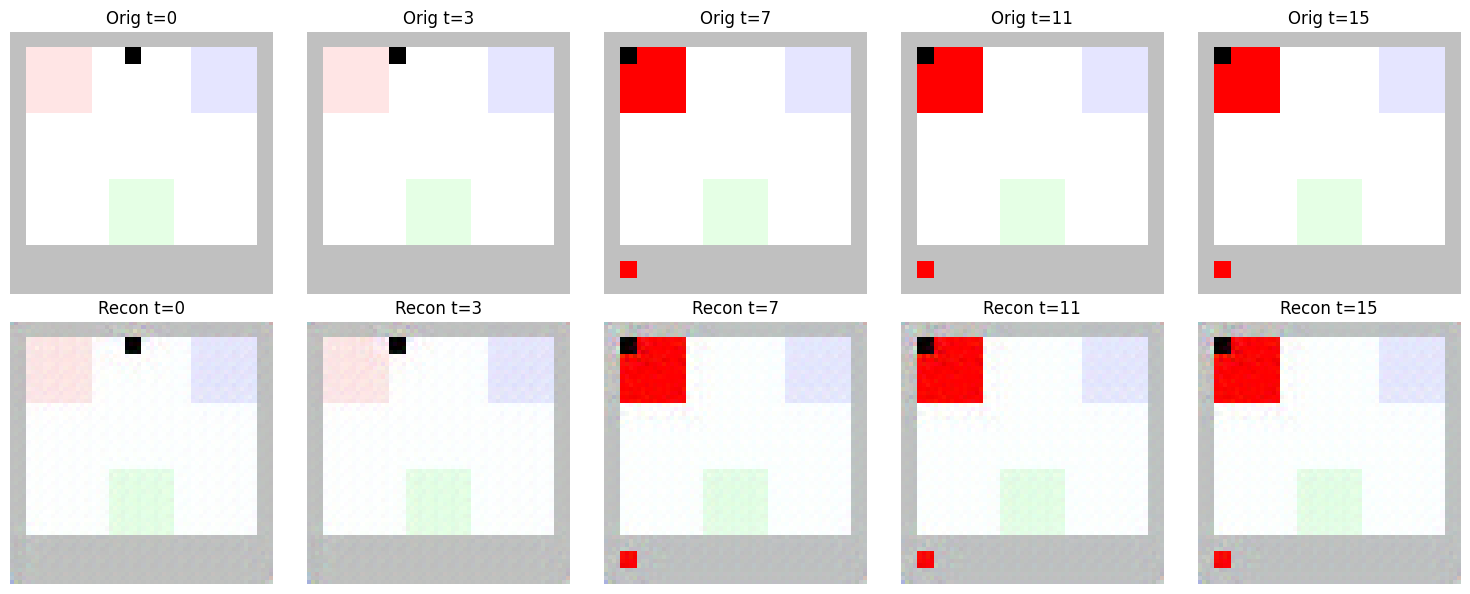

In [9]:
dim, dim_latent, num_latent_tokens, num_spatial_tokens = 256, 256, 256, 256
d=2
encoder_depth, decoder_depth, dynamics_depth = d, d, d
time_block_every=d
lpips_loss_weight=0.2 # default 
decor_auxx_loss_weight=0.1 # default
use_time_rnn = False # don't include an RNN

batch_size = 8 #16
num_train_steps=1000

accelerate_kwargs={"mixed_precision": "bf16"}
token_uses_time_block = True; time_block_every = d if token_uses_time_block else 1000

if SIMPLE_TOKENIZER:=False:
    # Tokenizer debug config suggested by gemini3 pro
    tk = VideoTokenizer(
        dim=dim,                  # Massive increase from 64/128 (Better feature capture)
        dim_latent=dim_latent,           # Larger bottleneck capacity
        patch_size=4,             # Keep this small
        num_latent_tokens=num_latent_tokens,    # CRITICAL: Keep this matched to patches (16x16)
        encoder_depth=encoder_depth,          # Deeper is better for reasoning about features
        decoder_depth=decoder_depth,
        time_block_every=time_block_every,       # More temporal blocks for video
        lpips_loss_weight=lpips_loss_weight,    # Strong perceptual signal
        per_image_patch_mask_prob=(0.0, 0.0),  # No masking during debugging
        decor_auxx_loss_weight = decor_auxx_loss_weight,
    ).to(device)

    from torch.optim import AdamW
    # 2) Train tokenizer (VideoTokenizerTrainer expects a TensorDataset and uses [0])
    tok_tr = VideoTokenizerTrainer(tk, tok_ds, batch_size=batch_size, num_train_steps=num_train_steps,
                                weight_decay=0,
                                optim_klass=AdamW,
                                #    learning_rate=1e-3,
                                accelerate_kwargs=accelerate_kwargs,)
    tok_tr(num_train_step=100)
else:
    from dreamer4._core import DataLoader
    from torch.optim import AdamW
    import numpy as np

    n_train_steps=500
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # A. Build Dataset

    from dreamer4._tokenizer import SimpleConvTokenizer
    dl = DataLoader(tok_ds, batch_size=16, shuffle=True)
    print(f"Dataset ready. Samples: {len(tok_ds)}")

    # B. Initialize Model
    tk = SimpleConvTokenizer(
        dim=64, 
        dim_latent=dim_latent, 
        down_steps=2,  # 16 tokens (4x4 grid)
        image_size=64,
    ).to(device)

    print(f"Overwriting latent parameter sizes for simplified tokenizer.")
    num_spatial_tokens = tk.num_latent_tokens
    num_latent_tokens = tk.num_latent_tokens

    optimizer = AdamW(tk.parameters(), lr=1e-3)

    # C. Quick Training Loop (Proof of Life)
    print(f"\nStarting Sanity Train ({n_train_steps} steps)...")
    tk.train()

    losses = []

    iterator = iter(dl)
    for i in range(n_train_steps):
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(dl)
            batch = next(iterator)
            
        video = batch.to(device) # (B, C, T, H, W)
        
        loss = tk(video)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        if i % 10 == 0:
            print(f"Step {i}: Loss = {loss.item():.4f}")

    # D. Visualization
    print("\nVisualizing Result...")
    tk.eval()

    # Get a fresh sample
    sample = next(iter(dl)).to(device)
    with torch.no_grad():
        latents = tk.encode(sample)
        recon = tk.decode(latents)

    # Pick first batch item, 5 evenly spaced frames
    idx = 0
    t_indices = np.linspace(0, sample.shape[2]-1, 5, dtype=int)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for i, t in enumerate(t_indices):
        # Original (Top)
        orig = sample[idx, :, t].permute(1,2,0).cpu().numpy()
        orig = (orig + 1) / 2 # [-1, 1] -> [0, 1]
        
        # Recon (Bottom)
        rec = recon[idx, :, t].permute(1,2,0).cpu().numpy()
        rec = (rec + 1) / 2
        
        axes[0, i].imshow(np.clip(orig, 0, 1))
        axes[0, i].set_title(f"Orig t={t}")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(np.clip(rec, 0, 1))
        axes[1, i].set_title(f"Recon t={t}")
        axes[1, i].axis('off')
        
        # Check specific pixel ranges
        if i == 0:
            print(f"Recon Range: min={rec.min():.2f}, max={rec.max():.2f}")

    plt.tight_layout()
    plt.show()

dynamics = DynamicsWorldModel(
    video_tokenizer=tk,
    dim=dim,
    dim_latent=dim_latent,
    max_steps=64,
    num_tasks=1,
    num_latent_tokens=num_latent_tokens,          # match tokenizer
    num_spatial_tokens=num_spatial_tokens,         # was 2 (too tiny), then 8 not big enough to track movement
    depth=dynamics_depth,                      # was default 4
    time_block_every=time_block_every,           # was 4
    pred_orig_latent=True,
    num_discrete_actions=env.action_space.n,
    attn_dim_head=32,
    prob_no_shortcut_train=0.4,   # give shortcut some presence
    num_residual_streams=1,
    use_time_rnn = use_time_rnn,
).to(device)
# 3) Train world model with BC (BehaviorCloneTrainer expects a dict batch and calls model(**batch))
bc_tr = BehaviorCloneTrainer(dynamics, bc_ds, batch_size=batch_size, num_train_steps=num_train_steps,
                                                            accelerate_kwargs=accelerate_kwargs,)


In [ ]:
# Check Latent Statistics
sample = next(iter(dl)).to(device) # (B, C, T, H, W)
with torch.no_grad():
    latents = tk.encode(sample)
    
print(f"Latent Mean: {latents.mean().item():.4f}")
print(f"Latent Std:  {latents.std().item():.4f}")
print(f"Latent Min:  {latents.min().item():.4f}")
print(f"Latent Max:  {latents.max().item():.4f}")

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def check_tokenizer_fidelity(tokenizer, video, num_frames=5):
    """
    Visualizes multiple frames to check reconstruction quality across time.
    Top Row: Original | Bottom Row: Reconstruction
    """
    device = next(tokenizer.parameters()).device
    video = video.to(device)
    
    # FIX: Ensure (1, C, T, H, W)
    if video.ndim == 4:
        video = video.unsqueeze(0)
        
    tokenizer.eval()
    with torch.no_grad():
        # Encode
        latents = tokenizer.tokenize(video) # (1, T, N, D)
        # Decode
        recon = tokenizer.decode(latents, height=64, width=64)
    tokenizer.train()

    # Calculate indices for frames to show (evenly spaced)
    T = video.shape[2]
    # If video is shorter than num_frames, just show all of them
    if T <= num_frames:
        indices = list(range(T))
    else:
        indices = np.linspace(0, T-1, num_frames, dtype=int)
    
    # Create grid: 2 Rows, N Columns
    fig, axes = plt.subplots(2, len(indices), figsize=(3 * len(indices), 6))
    
    # Handle single frame case (matplotlib axes subtleties)
    if len(indices) == 1:
        axes = axes.reshape(2, 1)

    print(f"--- Stats for Frame {indices[0]} ---")
    
    for i, t_idx in enumerate(indices):
        # 1. Process Original
        # Un-normalize: [-1, 1] -> [0, 1]
        orig_img = (video[0, :, t_idx] + 1) / 2
        orig_img = orig_img.permute(1,2,0).cpu().clamp(0,1).numpy()
        
        # 2. Process Reconstruction
        recon_img = (recon[0, :, t_idx] + 1) / 2
        recon_img = recon_img.permute(1,2,0).cpu().clamp(0,1).numpy()
        
        # Print stats only for the first frame to keep logs clean
        if i == 0:
            print(f"Original range:      min={orig_img.min():.2f}, max={orig_img.max():.2f}")
            print(f"Reconstructed range: min={recon_img.min():.2f}, max={recon_img.max():.2f}")

        # 3. Plot Original (Top Row)
        axes[0, i].imshow(orig_img)
        axes[0, i].set_title(f"Orig (t={t_idx})")
        axes[0, i].axis('off')
        
        # 4. Plot Reconstruction (Bottom Row)
        axes[1, i].imshow(recon_img)
        axes[1, i].set_title(f"Recon (t={t_idx})")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage:
# sample = bc_ds[0]
# video = sample["video"].to(tk.device)   
# check_tokenizer_fidelity(tk, video)

sample = bc_ds[random.randint(0, len(bc_ds)-1)]
video = sample["video"].to(tk.device)   
check_tokenizer_fidelity(tk, video)  # use BC video for more variety

In [ ]:
video[:,0,...].min(), video[:,0,...].max()

In [ ]:
## Tokenizer Training Loop ##

# first set lpips loss to 0
# tk.lpips_loss_weight = 0.0

losses = []
if True:
    tok_tr.train()
    # bc_tr.train()
    print(f'{tk.training=}')
    
    # while tok_tr.total_steps < 1e3:
    for _ in range(100):
        sample = bc_ds[random.randint(0, len(bc_ds)-1)]
        video = sample["video"].to(tk.device)   
        # Run the fixed sanity check
        check_tokenizer_fidelity(tk, video)
        # is the model in train or eval?
        audit_gpu_memory()
        losses.append(tok_tr())

        # if tok_tr.total_steps > 1500:
            # now set lpips loss to 1.0
            # tk.lpips_loss_weight = 1.0


In [ ]:
# plot the losses
import matplotlib.pyplot as plt
import itertools
flat_list = [
    x
    for xs in losses
    for x in xs
]

plt.plot(flat_list)
plt.show()

In [ ]:
tok_tr.train()
bc_tr.train()
audit_gpu_memory()

tok_tr()
audit_gpu_memory()
bc_tr()

Visualize the next frame

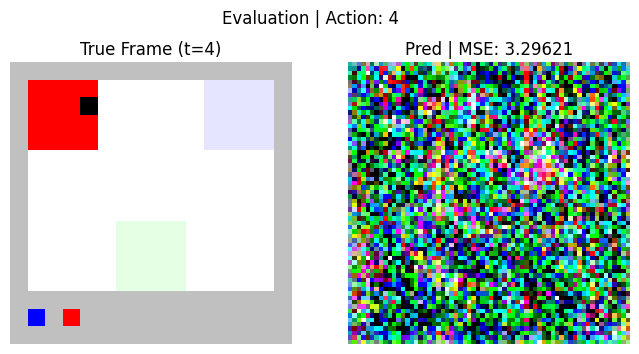

Next-frame MSE: 3.2962095737457275


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def robust_next_frame_eval(
    tokenizer,
    dynamics,
    video,             # (C,T,H,W)
    discrete_actions,  # (T, 1) or (T,)
    k=4,
    num_steps=4
):
    # Get model device and dtype (crucial for mixed precision)
    param = next(dynamics.parameters())
    device = param.device
    dtype = param.dtype
    
    # 1. Setup Video & Batch Dim
    if video.ndim == 4: video = video.unsqueeze(0) # (1, C, T, H, W)
    
    # Cast video to match model (e.g. bfloat16) to prevent crashes
    video = video.to(device=device, dtype=dtype)
    B, C, T, H, W = video.shape

    # 2. Setup Actions
    if discrete_actions is not None:
        da = discrete_actions.to(device)
        
        # Ensure (1, T, 1) shape
        if da.ndim == 1: 
            da = da.unsqueeze(0).unsqueeze(-1) 
        elif da.ndim == 2:
            da = da.unsqueeze(0)
            
        # Slice: We need actions up to step k
        da_input = da[:, :k+1] 
    else:
        da_input = None

    # 3. Tokenize History (0 to k-1)
    # SimpleConvTokenizer returns (B, T, N, D)
    lat_past = tokenizer.tokenize(video[:, :, :k]) 
    
    # World Model expects (B, T, V, N, D) -> Add View Dim if missing
    if lat_past.ndim == 4: lat_past = lat_past.unsqueeze(2)
    
    # 4. Init Target Latent (Frame k) as Noise
    n, d = lat_past.shape[-2:]
    lat_next = torch.randn((1, 1, 1, n, d), device=device, dtype=dtype)

    # 5. Schedule Loop (DDIM-style)
    step_size = dynamics.max_steps // num_steps
    levels = torch.arange(0, dynamics.max_steps, step_size, device=device, dtype=torch.long)
    
    for level in levels:
        # Cat past history with current noisy prediction
        lat_in = torch.cat([lat_past, lat_next], dim=1)

        # Signal levels (Time embeddings)
        sig_next = level.view(1, 1)
        sig_past = torch.full((1, k), dynamics.max_steps - 1, device=device, dtype=torch.long)
        sig_full = torch.cat([sig_past, sig_next], dim=1)

        # Predict
        pred, _ = dynamics.forward(
            latents=lat_in,
            signal_levels=sig_full,
            step_sizes=step_size,
            discrete_actions=da_input,
            latent_is_noised=True,
            return_pred_only=True,
            return_intermediates=True,
            latent_has_view_dim=True,
        )
        
        if isinstance(pred, tuple): pred = pred[0]
        
        # Extract prediction for the last frame (k)
        model_out = pred[:, -1:]
        
        # Flow Matching Step
        if dynamics.pred_orig_latent:
            t_curr = level.float() / dynamics.max_steps
            t_curr = torch.clamp(t_curr, 0.0, 0.999).to(dtype) # Match dtype
            flow = (model_out - lat_next) / (1.0 - t_curr)
        else:
            flow = model_out
            
        dt = step_size / dynamics.max_steps
        lat_next = lat_next + flow * dt

    # 6. Decode
    # Prepare latent for decoder: (1, 1, N, D) -> (B, T, N, D)
    pred_lat_seq = lat_next[:, :, 0] # Remove view dim -> (1, 1, N, D)
    
    pred_lat_seq = torch.clamp(pred_lat_seq, -3.0, 3.0)

    # SimpleConvTokenizer.decode returns (B, C, T, H, W)
    pred_video = tokenizer.decode(pred_lat_seq, height=H, width=W)
    
    return {
        "pred_frame": pred_video[0, :, 0].float().cpu(), # Return to float32 for plotting
        "true_frame": video[0, :, k].float().cpu(),
        "action": da_input[0, k-1, 0].cpu() if da_input is not None else None,
    }

def viz_robust_frame(tokenizer, dynamics, video, discrete_actions, k=4, num_steps=4, title=None):
    title = title or f"Robust Next-frame Prediction at t={k}"
    
    out = robust_next_frame_eval(tokenizer, dynamics, video, discrete_actions, k, num_steps)
    
    true_f = out['true_frame']
    pred_f = out['pred_frame']
    action = out.get('action', 'n/a')
    
    mse = F.mse_loss(true_f, pred_f).item()
    
    # Helper to denormalize [-1, 1] -> [0, 1] for plotting
    def to_img(x): 
        # x shape (C, H, W)
        x = (x + 1) / 2
        return x.permute(1,2,0).clamp(0,1).numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    axes[0].imshow(to_img(true_f))
    axes[0].set_title(f"True Frame (t={k})")
    axes[0].axis("off")
    
    axes[1].imshow(to_img(pred_f))
    axes[1].set_title(f"Pred | MSE: {mse:.5f}")
    axes[1].axis("off")
    
    title += f" | Action: {action}"
    if title: fig.suptitle(title)
    plt.show()
    
    return mse

# --- USAGE ---
sample = bc_ds[0]
video = sample["video"].to(tk.device)            
acts  = sample.get("discrete_actions").to(tk.device)

mse = viz_robust_frame(
    tokenizer=tk,
    dynamics=dynamics,
    video=video,
    discrete_actions=acts,
    k=4,
    num_steps=8, # More steps = better quality
    title="Evaluation"
)
print("Next-frame MSE:", mse)

In [ ]:
# show all 16 frames of the video in a grid
def plot_video_grid(video, rows=4, cols=4, title="Video Grid"):
    action_map = {0: 'none', 2: 'up', 1: 'down', 3: 'right', 4:'left'}

    v = canonicalize_cthw(get_video_from_sample(video))  # (C,T,H,W)
    C,T,H,W = v.shape
    assert rows * cols >= T, "Not enough grid cells for all frames"
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            axes[i,j].axis("off")
            if idx < T:
                img = v[:, idx].permute(1,2,0).cpu().numpy()
                axes[i,j].imshow(img)
                title=f"t={idx} Action: {action_map.get(sample['discrete_actions'][idx].item(), 'N/A')}"
                axes[i,j].set_title(title)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# plot_video_grid(sample, rows=4, cols=4, title="Sample Video from BC Dataset")

In [ ]:
import torch, numpy as np
import torch.nn.functional as F

@torch.no_grad()
def eval_open_loop_k_steps(tokenizer, dynamics, video, k=4, H=8, actions=None, rewards=None):
    """
    Predict H future frames given a rolling window of the last k frames.
    Keeps the context fixed at length k (so model input is always k+1).
    Returns per-step MSE and mean MSE.
    """
    device = next(dynamics.parameters()).device

    # standardize to (1,C,T,H,W)
    if video.ndim == 4:
        video = video.unsqueeze(0)
    elif video.ndim != 5:
        raise ValueError(f"video must be (C,T,H,W) or (1,C,T,H,W); got {tuple(video.shape)}")
    video = video.to(device)
    B,C,T,VH,VW = video.shape
    if B != 1: raise ValueError("Only B=1 supported for this eval.")
    if T <= k: raise ValueError(f"Need T > k (T={T}, k={k}).")
    if H > (T - k): H = T - k  # clip horizon if needed

    # optional A/R to (1,T,...) with right padding if short
    def _prep_opt(x, need_len):
        if x is None: return None
        x = x.to(device)
        if x.ndim == 1: x = x.unsqueeze(0)            # (1,T)
        elif x.ndim == 2 and x.shape[0] != 1: x = x.unsqueeze(0)  # (1,T,NA?)
        if x.shape[1] < need_len:
            pad = torch.zeros((x.shape[0], need_len - x.shape[1], *x.shape[2:]),
                              dtype=x.dtype, device=x.device)
            x = torch.cat([x, pad], dim=1)
        return x

    actions = _prep_opt(actions, need_len=T)
    rewards = _prep_opt(rewards, need_len=T)

    # tokenize initial history (first k)
    lat_past = tokenizer.tokenize(video[:, :, :k]).unsqueeze(2)  # (1,k,1,n,d)
    n, d = lat_past.shape[-2], lat_past.shape[-1]

    per_step_mse = []

    for step in range(H):
        # always condition on last k -> input length is k+1
        lat_slot = torch.randn((1,1,1,n,d), device=device)
        lat_in = torch.cat([lat_past, lat_slot], dim=1)          # (1,k+1,1,n,d)

        # align A/R to last k (then pad one)
        da = None
        if actions is not None:
            a_k = actions[:, step:step+k]                         # (1,k,NA?) or (1,k)
            pad = torch.zeros_like(a_k[:, :1])                    # (1,1,...)
            da = torch.cat([a_k, pad], dim=1)                     # (1,k+1,...)

        rw = None
        if rewards is not None:
            r_k = rewards[:, step:step+k]                         # (1,k)
            rw  = torch.cat([r_k, torch.zeros_like(r_k[:, :1])], dim=1)  # (1,k+1)

        # inference schedule for exactly k+1 tokens
        step_size = torch.tensor(1, device=device)
        signal_levels = torch.full((1, k+1), dynamics.max_steps - 1,
                                   dtype=torch.long, device=device)

        # predict next latent (one denoise step)
        pred, _ = dynamics.forward(
            latents=lat_in,
            signal_levels=signal_levels,
            step_sizes=step_size,
            rewards=rw,
            discrete_actions=da,
            latent_is_noised=True,
            return_pred_only=True,
            return_intermediates=True,
            latent_has_view_dim=True,
        )
        if isinstance(pred, tuple): pred = pred[0]                # strip proprio if present
        pred_next_lat = pred[:, -1, 0]                            # (1,n,d)

        # decode and compare to ground truth at t = k+step
        pred_frame = tokenizer.decode(pred_next_lat, height=VH, width=VW)[0, :, 0]
        true_frame = video[0, :, k + step]
        per_step_mse.append(F.mse_loss(pred_frame, true_frame).item())

        # roll history window: drop oldest, append GT next latent
        gt_next_lat = tokenizer.tokenize(video[:, :, k + step : k + step + 1])  # (1,1,n,d)
        lat_past = torch.cat([lat_past[:, 1:], gt_next_lat.unsqueeze(2)], dim=1)  # keep length k

    return {
        "per_step_mse": np.array(per_step_mse, dtype=np.float32),
        "mean_mse": float(np.mean(per_step_mse)),
        "k": k,
        "H": H,
        "T": int(T),
    }


import torch, numpy as np
import matplotlib.pyplot as plt

sample = bc_ds[0]
video = sample["video"]            # (C,T,H,W)
acts  = sample.get("discrete_actions")
rews  = sample.get("rewards")

print("video shape:", tuple(video.shape))  # helpful debug
k, H = 4, 8

out = eval_open_loop_k_steps(
    tokenizer=tk,
    dynamics=dynamics,
    video=video,
    k=k,
    H=H,                 # will auto-clip to T-k if needed
    actions=acts,
    rewards=rews
)

print("T, k, (possibly clipped) H:", out["T"], out["k"], out["H"])
print("Per-step MSE:", out["per_step_mse"], "Mean:", out["mean_mse"])


# quick plot
plt.figure(figsize=(5,3))
plt.plot(range(1, H+1), out["per_step_mse"], marker="o")
plt.xlabel("Prediction step (t = k + step)")
plt.ylabel("MSE")
plt.title(f"Open-loop {H}-step MSE (k={k})")
plt.tight_layout(); plt.show()

In [12]:
# --- EVAL HARNESS FOR PINPAD + DYNAMICS ---

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

@torch.no_grad()
def run_env_eval(
    env,
    dynamics,                # DynamicsWorldModel (already paired with tokenizer)
    tokenizer=None,          # VideoTokenizer or None
    episodes=5,
    max_steps=64,            # steps per episode (caps rollout inside interact_with_env)
    env_is_vectorized=False,
    show_first_k=8,          # how many frames to visualize
    show=True                # set False for headless metric-only
):
    device = next(dynamics.parameters()).device

    # put model in eval for stable behavior
    was_training = dynamics.training
    dynamics.eval()

    ep_stats = []
    visuals = []  # optional (video, recon) pairs for first few episodes

    for ep in range(episodes):
        exp = dynamics.interact_with_env(
            env,
            max_timesteps=max_steps,
            env_is_vectorized=env_is_vectorized,
            use_time_cache=True,
            store_agent_embed=False,
            store_old_action_unembeds=False
        )

        # rewards: (B, T) where B=1 here
        rewards = exp.rewards.squeeze(0) if exp.rewards is not None else torch.zeros(0, device=device)
        total_r = rewards.sum().item()
        ep_len  = rewards.numel()
        # PinPad marks success with +10 reward on success step
        success = (rewards.max().item() >= 9.99) if rewards.numel() > 0 else False

        stat = dict(reward=total_r, length=ep_len, success=bool(success))
        ep_stats.append(stat)

        if show and exp.video is not None and tokenizer is not None:
            # exp.video: (B,C,T,H,W); exp.latents: (B,T, [V=1], N, D) or (B,T,N,D)
            video = exp.video[0].detach().cpu()                      # (C,T,H,W)
            latents = exp.latents.to(device)
            # decode latents back to video for comparison
            C, T, H, W = video.shape
            lat_for_dec = latents
            if lat_for_dec.ndim == 5:  # (B,T,1,N,D) -> (B,T,N,D)
                lat_for_dec = lat_for_dec[..., 0, :, :]
            recon = tokenizer.decode(lat_for_dec, height=H, width=W)[0].detach().cpu()  # (C,T,H,W)
            visuals.append((video, recon))

            # visualize a few frames inline
            t_show = min(T, show_first_k)
            fig, axes = plt.subplots(2, t_show, figsize=(3*t_show, 6))
            for i in range(t_show):
                axes[0, i].imshow(video[:, i].permute(1,2,0).clamp(0,1).numpy())
                axes[0, i].set_title(f"ep {ep} | orig t={i}")
                axes[0, i].axis("off")

                axes[1, i].imshow(recon[:, i].permute(1,2,0).clamp(0,1).numpy())
                axes[1, i].set_title(f"ep {ep} | recon t={i}")
                axes[1, i].axis("off")

            fig.suptitle(f"Reward={total_r:.2f} | Len={ep_len} | Success={success}")
            plt.tight_layout()
            display(fig)
            plt.close(fig)

    # restore training state
    dynamics.train(was_training)

    # aggregate metrics
    rewards = [s["reward"] for s in ep_stats]
    lengths = [s["length"] for s in ep_stats]
    successes = [s["success"] for s in ep_stats]

    summary = dict(
        episodes=episodes,
        avg_reward=float(np.mean(rewards)) if rewards else 0.0,
        avg_length=float(np.mean(lengths)) if lengths else 0.0,
        success_rate=float(np.mean(successes)) if successes else 0.0,
        per_episode=ep_stats,
        visuals=visuals,  # list of (video, recon), only when show=True & tokenizer provided
        d_actions=exp.actions[0].cpu() if exp.actions is not None else None,
    )

    print(
        f"[EVAL] episodes={episodes} | "
        f"avg_reward={summary['avg_reward']:.3f} | "
        f"avg_len={summary['avg_length']:.1f} | "
        f"success_rate={summary['success_rate']*100:.1f}%"
    )
    return summary


In [13]:
# Convert action indices to (dx, dy) movements for gut check

pinpad_actions = [(0, 0), (0, 2), (0, -2), (2, 0), (-2, 0)]
# for da in summary['d_actions'][0, :10]: 
for da in sample['discrete_actions']:
    print(f"Action taken: {pinpad_actions[da.item()]}")

Action taken: (0, -2)
Action taken: (2, 0)
Action taken: (2, 0)
Action taken: (2, 0)
Action taken: (0, -2)
Action taken: (0, -2)
Action taken: (0, -2)
Action taken: (0, 0)
Action taken: (0, -2)
Action taken: (-2, 0)
Action taken: (0, -2)
Action taken: (0, -2)
Action taken: (2, 0)
Action taken: (-2, 0)
Action taken: (0, -2)
Action taken: (0, -2)


In [15]:
bc_ds[0]['rewards']

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0200, 0.0000])

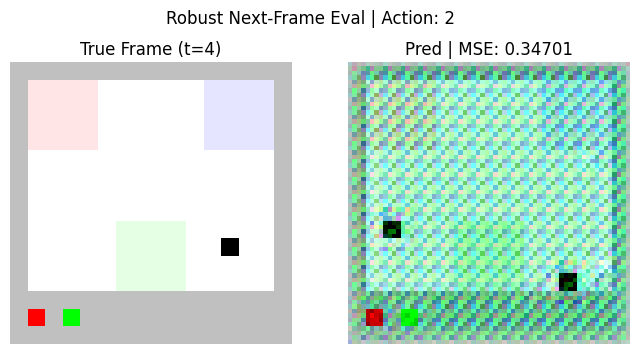

Next-frame MSE: 0.3470117151737213
[EVAL] episodes=5 | avg_reward=2.028 | avg_len=100.0 | success_rate=20.0%
WARN: Skipping tokenizer training.
Trained for 1000 updates. New total: 31785.


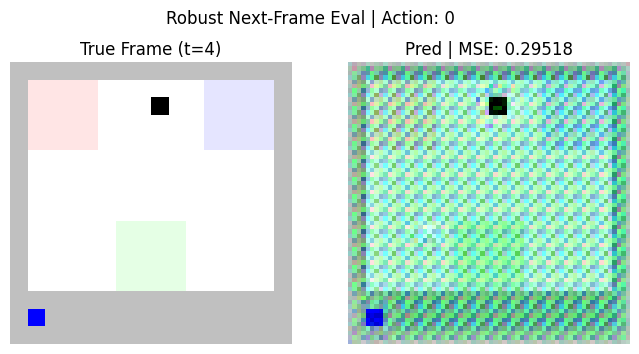

Next-frame MSE: 0.29518046975135803
[EVAL] episodes=5 | avg_reward=0.012 | avg_len=100.0 | success_rate=0.0%
WARN: Skipping tokenizer training.
Trained for 1000 updates. New total: 32785.


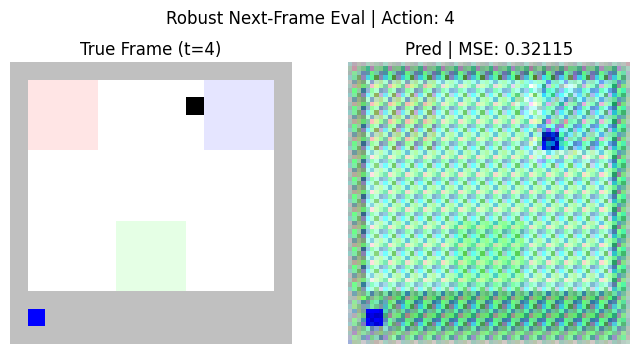

Next-frame MSE: 0.3211521804332733
[EVAL] episodes=5 | avg_reward=0.012 | avg_len=100.0 | success_rate=0.0%
WARN: Skipping tokenizer training.


KeyboardInterrupt: 

In [19]:
# Main training loop
import torch, numpy as np, random
import matplotlib.pyplot as plt


losses = []
for _ in range(50):
    sample = bc_ds[random.randint(0, len(bc_ds)-1)]
    # ... (your existing data loading code) ...
    video = sample["video"].to(tk.device)
    acts  = sample.get("discrete_actions").to(tk.device)

    tk.eval()
    bc_tr.eval()

    # if not SIMPLE_TOKENIZER:
    mse = viz_robust_frame(
        tokenizer=tk,
        dynamics=dynamics,
        video=video,
        discrete_actions=acts,
        k=4,
        num_steps=16,
        title="Robust Next-Frame Eval"
    )
    print("Next-frame MSE:", mse)
    if False:

        k, H = 4, 8
        mets = eval_open_loop_k_steps(
            tokenizer=tk,
            dynamics=dynamics,
            video=video,
            k=k,
            H=H,                 # will auto-clip to T-k if needed
            actions=acts,
            rewards=rews
        )

        print("T, k, (possibly clipped) H:", mets["T"], mets["k"], mets["H"])
        print("Per-step MSE:", mets["per_step_mse"], "Mean:", mets["mean_mse"])

    if DO_EVAL:=True:
        # set to eval
        tk.eval()
        dynamics.eval()

        summary = run_env_eval(
            env=env,
            dynamics=dynamics,
            tokenizer=tk,   # pass None to skip recon visuals
            episodes=5,
            max_steps=100,
            show_first_k=8,
            show=False
        )

        # set to training mode
        # tk.train()
        dynamics.train()

        # tok_tr()
        print(f"WARN: Skipping tokenizer training.")
        losses.append(bc_tr())

In [ ]:
# plot the losses
import matplotlib.pyplot as plt
import itertools
flat_list = [
    x
    for xs in losses
    for x in xs
]

plt.plot(flat_list)
plt.show()

[[array([13.182812], dtype=float32),
  array([9.369869], dtype=float32),
  array([20.185175], dtype=float32),
  array([12.515308], dtype=float32),
  array([15.418476], dtype=float32),
  array([11.811911], dtype=float32),
  array([10.751592], dtype=float32),
  array([12.172527], dtype=float32),
  array([19.021225], dtype=float32),
  array([23.669376], dtype=float32),
  array([12.247238], dtype=float32),
  array([16.660088], dtype=float32),
  array([11.557357], dtype=float32),
  array([9.193662], dtype=float32),
  array([8.889807], dtype=float32),
  array([22.634272], dtype=float32),
  array([15.119692], dtype=float32),
  array([8.890668], dtype=float32),
  array([13.45501], dtype=float32),
  array([23.767685], dtype=float32),
  array([17.326885], dtype=float32),
  array([12.22761], dtype=float32),
  array([12.736413], dtype=float32),
  array([13.081294], dtype=float32),
  array([12.756534], dtype=float32),
  array([16.790756], dtype=float32),
  array([15.72342], dtype=float32),
  array(

In [ ]:
if DO_PLOT:=True:
    # quick plot
    plt.figure(figsize=(5,3))
    plt.plot(range(1, H+1), mets["per_step_mse"], marker="o")
    plt.xlabel("Prediction step (t = k + step)")
    plt.ylabel("MSE")
    plt.title(f"Open-loop {H}-step MSE (k={k})")
    plt.tight_layout(); plt.show(block=False)

    # assuming you already have:
    # env          = PinPad(...) or your wrapped env (normalizes to [0,1])
    # tokenizer    = VideoTokenizer(...); tokenizer.eval()
    # dynamics     = DynamicsWorldModel(..., video_tokenizer=tokenizer, ...); dynamics.eval()
    # (optionally load weights for both)


In [ ]:
if DO_EVAL:=True:
    # set to eval
    tk.eval()
    dynamics.eval()

    summary = run_env_eval(
        env=env,
        dynamics=dynamics,
        tokenizer=tk,   # pass None to skip recon visuals
        episodes=5,
        max_steps=100,
        show_first_k=8,
        show=False
    )

    mets.update(summary)

    for k,v in mets.items():
        print(f"{k} {v}")


    # visualize out["pred_frame"] vs out["target_frame"]


In [ ]:


summary = run_env_eval(
    env=env,
    dynamics=dynamics,
    tokenizer=tk,   # pass None to skip recon visuals
    episodes=1,
    max_steps=100,
    show_first_k=100,
    show=True
)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()